In [ ]:
#訓練用データとテストデータを読み込む
#　サイズは224pxにリサイズ
import tensorflow as tf

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/train",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=True
)


test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/test",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=True
)


Found 300 files belonging to 2 classes.
Found 100 files belonging to 2 classes.


In [6]:
# データの詳細を表示する
list(train_dataset.as_numpy_iterator())[0]


(array([[[[2.23000000e+02, 2.25000000e+02, 2.12000000e+02],
          [2.22986603e+02, 2.24988846e+02, 2.11997772e+02],
          [2.20977676e+02, 2.23314728e+02, 2.11662949e+02],
          ...,
          [2.14000000e+02, 2.15000000e+02, 2.10000000e+02],
          [2.14000000e+02, 2.15000000e+02, 2.10000000e+02],
          [2.14000000e+02, 2.15000000e+02, 2.10000000e+02]],
 
         [[2.22805801e+02, 2.24828125e+02, 2.11848221e+02],
          [2.22792664e+02, 2.24817078e+02, 2.11846085e+02],
          [2.20822601e+02, 2.23158646e+02, 2.11525452e+02],
          ...,
          [2.13965012e+02, 2.14976181e+02, 2.09987335e+02],
          [2.13966507e+02, 2.14977661e+02, 2.09988831e+02],
          [2.13966522e+02, 2.14977676e+02, 2.09988846e+02]],
 
         [[1.93676331e+02, 1.99046875e+02, 1.89080353e+02],
          [1.93702057e+02, 1.99051514e+02, 1.89092422e+02],
          [1.97561478e+02, 1.99747314e+02, 1.90901794e+02],
          ...,
          [2.08716980e+02, 2.11402252e+02, 2.0808

In [7]:
# 分類名（no／yes）をリストとして格納する
class_names = train_dataset.class_names
class_names

['cat', 'dog']

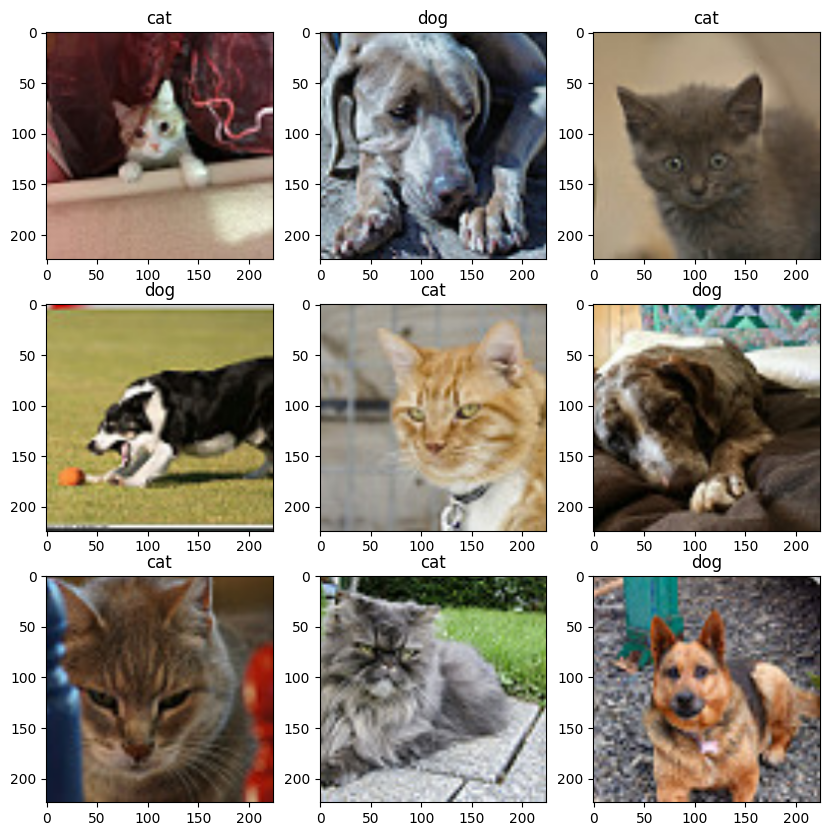

In [10]:
# 訓練データの一部を表示して確認
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [11]:
# 画像の水増しをする関数の定義
def flip_left_right(image, label):   # 左右反転
    image = tf.image.flip_left_right(image)
    return image, label

def flip_up_down(image, label):      # 上下反転
    image = tf.image.flip_up_down(image)
    return image, label

def rot90(image, label):             # 反時計回りに90度回転
    image = tf.image.rot90(image)
    return image, label

def rot180(image, label):            # 反時計回りに180度回転
    image = tf.image.rot90(image, k=2)
    return image, label

def rot270(image, label):            # 反時計回りに270度回転
    image = tf.image.rot90(image, k=3)
    return image, label

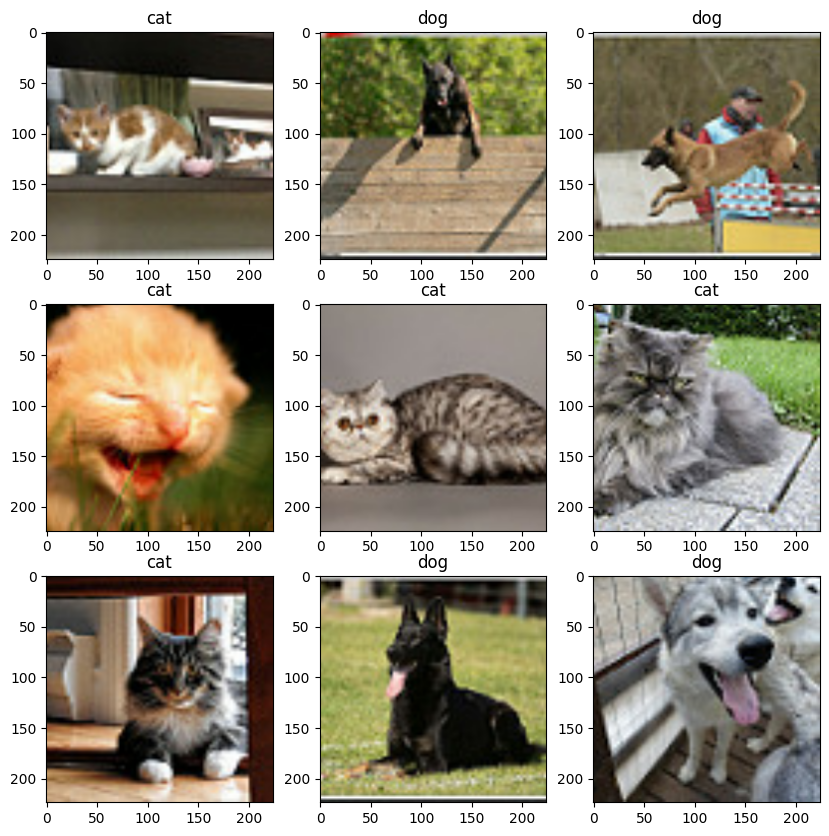

In [12]:
# 画像の水増し処理の実行
train_dataset_lr     = train_dataset.map(flip_left_right)
train_dataset_ud     = train_dataset.map(flip_up_down)
train_dataset_rot90  = train_dataset.map(rot90)
train_dataset_rot180 = train_dataset.map(rot180)
train_dataset_rot270 = train_dataset.map(rot270)

# 水増ししたデータを訓練データに追加する
train_dataset = train_dataset.concatenate(train_dataset_lr)
train_dataset = train_dataset.concatenate(train_dataset_ud)
train_dataset = train_dataset.concatenate(train_dataset_rot90)
train_dataset = train_dataset.concatenate(train_dataset_rot180)
train_dataset = train_dataset.concatenate(train_dataset_rot270)

# データをシャッフルする
train_dataset = train_dataset.shuffle(32)

# 訓練データの一部を表示して確認
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [14]:
# MobileNetV2モデルを作成する
input_layer = tf.keras.Input(shape=(224, 224, 3))   # 入力層
l_layer = tf.keras.applications.mobilenet_v2.preprocess_input(input_layer)   # 前処理（正規化）をする層

base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(
    input_shape=(224, 224, 3),
    input_tensor=l_layer,
    include_top=False,
    weights="imagenet",
    pooling='avg'
)
base_model.trainable = False

In [16]:
# Dense層を追加する
output_layer = tf.keras.layers.Dense(1, activation='sigmoid')

In [17]:
# base_modelに先ほどのDense層を追加したモデルを作成する
model = tf.keras.Sequential([
    base_model,
    output_layer
])

In [18]:
# modelをcompileする
model.compile(optimizer="adam",
              loss='binary_crossentropy',
              metrics=["accuracy"])

In [19]:
# modelに学習させる
model.fit(train_dataset, epochs=20)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 28s 411ms/step - accuracy: 0.8083 - loss: 0.4069
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 416ms/step - accuracy: 0.9189 - loss: 0.2209
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 410ms/step - accuracy: 0.9411 - loss: 0.1703
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 414ms/step - accuracy: 0.9583 - loss: 0.1394
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 416ms/step - accuracy: 0.9650 - loss: 0.1201
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 414ms/step - accuracy: 0.9733 - loss: 0.1042
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 415ms/step - accuracy: 0.9789 - loss: 0.0921
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 412ms/step - accuracy: 0.9817 - loss: 0.0812
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 415ms/step - accuracy: 0.9844 - loss: 0.0722
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 414ms/step - accuracy: 0.9856 - loss: 0.0661
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 416ms/step - accuracy: 0.9861 - loss: 0.0595
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 26

In [20]:
# テストデータで分類を実行する
pred_data = model.predict(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 548ms/step


In [21]:
# 分類した結果を確認する
pred_data

array([[9.9987072e-01],
       [9.9869990e-01],
       [9.8667055e-01],
       [1.5736588e-04],
       [9.9997115e-01],
       [7.5550720e-02],
       [3.4888875e-05],
       [9.9998856e-01],
       [9.9993855e-01],
       [2.6384235e-04],
       [9.9900776e-01],
       [9.9984646e-01],
       [9.9994385e-01],
       [9.9999827e-01],
       [2.4744787e-03],
       [9.9982011e-01],
       [4.8008776e-01],
       [9.9828452e-01],
       [4.1872296e-03],
       [9.9923182e-01],
       [8.4247952e-03],
       [2.2972547e-01],
       [5.8744573e-03],
       [9.7962517e-01],
       [1.1364791e-05],
       [9.1356022e-04],
       [9.9938869e-01],
       [9.9110574e-01],
       [9.9995112e-01],
       [9.9708670e-01],
       [4.5376495e-04],
       [9.9997586e-01],
       [9.9796689e-01],
       [1.6126227e-02],
       [3.6896250e-04],
       [9.9867880e-01],
       [1.4132075e-04],
       [8.9146808e-04],
       [2.4025142e-01],
       [3.1305934e-04],
       [3.1795833e-04],
       [3.933878

In [22]:
# evaluate()でモデルの性能を評価する
model.evaluate(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 303ms/step - accuracy: 0.9600 - loss: 0.0673


[0.06729337573051453, 0.9599999785423279]